In [47]:
import kagglehub
import pandas as pd
import numpy as np
import os

try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'))
    print(" Path to dataset files:", path)
    
except Exception as e:
    print(f"Something failed... {e}")

data.head()

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [48]:
data.columns = data.columns.str.strip()

print(data.shape)

print(data.dtypes)

(225745, 79)
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object


In [49]:
print(data.isnull().sum())
print('----')
print(data['Label'].value_counts())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64
----
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [50]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1',
    'Avg Fwd Segment Size',
    'Subflow fwd bytes',
    'Subflow fwd packets',
    'Subflow bwd Packets',
    'Subflow bwd bytes',
    'Packet Length Variance' 
]

data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19628
           1       1.00      1.00      1.00     25515

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



Fwd Packet Length Max          0.121316
Fwd Packet Length Mean         0.092828
Fwd IAT Total                  0.068608
Subflow Fwd Packets            0.056100
Fwd IAT Std                    0.052758
Total Length of Fwd Packets    0.051950
act_data_pkt_fwd               0.048193
Init_Win_bytes_forward         0.047941
Fwd Packet Length Std          0.047050
Fwd Header Length              0.044169
dtype: float64


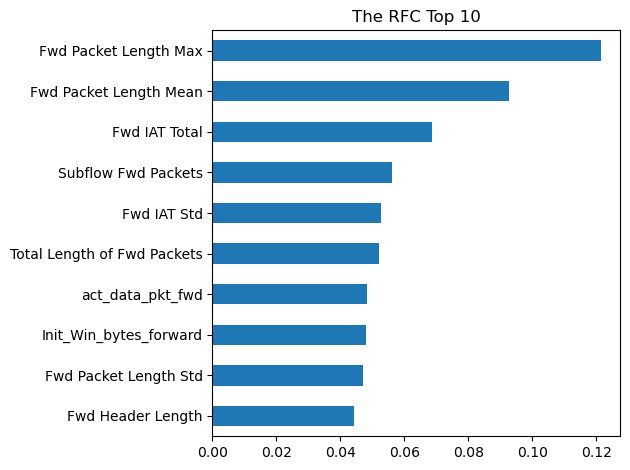

In [53]:
import matplotlib.pyplot as plt

rfc_importance = RandomForestClassifier(n_estimators = 100, random_state=1)
rfc_importance.fit(X,y)

importance = pd.Series(rfc_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).sort_values().plot(kind='barh')
plt.title('The RFC Top 10')
plt.tight_layout()
plt.show()